In [1]:
import polars as pl
import arviz as az
import numpy as np
import pymc as pm

from matplotlib import pylab as plt
from scipy import stats

import plotnine as p9

# Questions 1 - 4 Written

1. 2
2. 3
3. 1 and 4 
    - 4 bc P(monday|rain)P(rain) = P(rain|monday)P(monday)
    so P(Monday|rain) = (P(rain|monday)P(monday)) / p(rain) by bayes theorem

4. The probability of water is .7 is our belief in the presence of water on the globe. We have no objective way of knowing the exact amount and we will always have some error bar around this estimate. We can continue to refine this estimate with more data but will never be sure of the exact amount. 

# Questions w/ Code

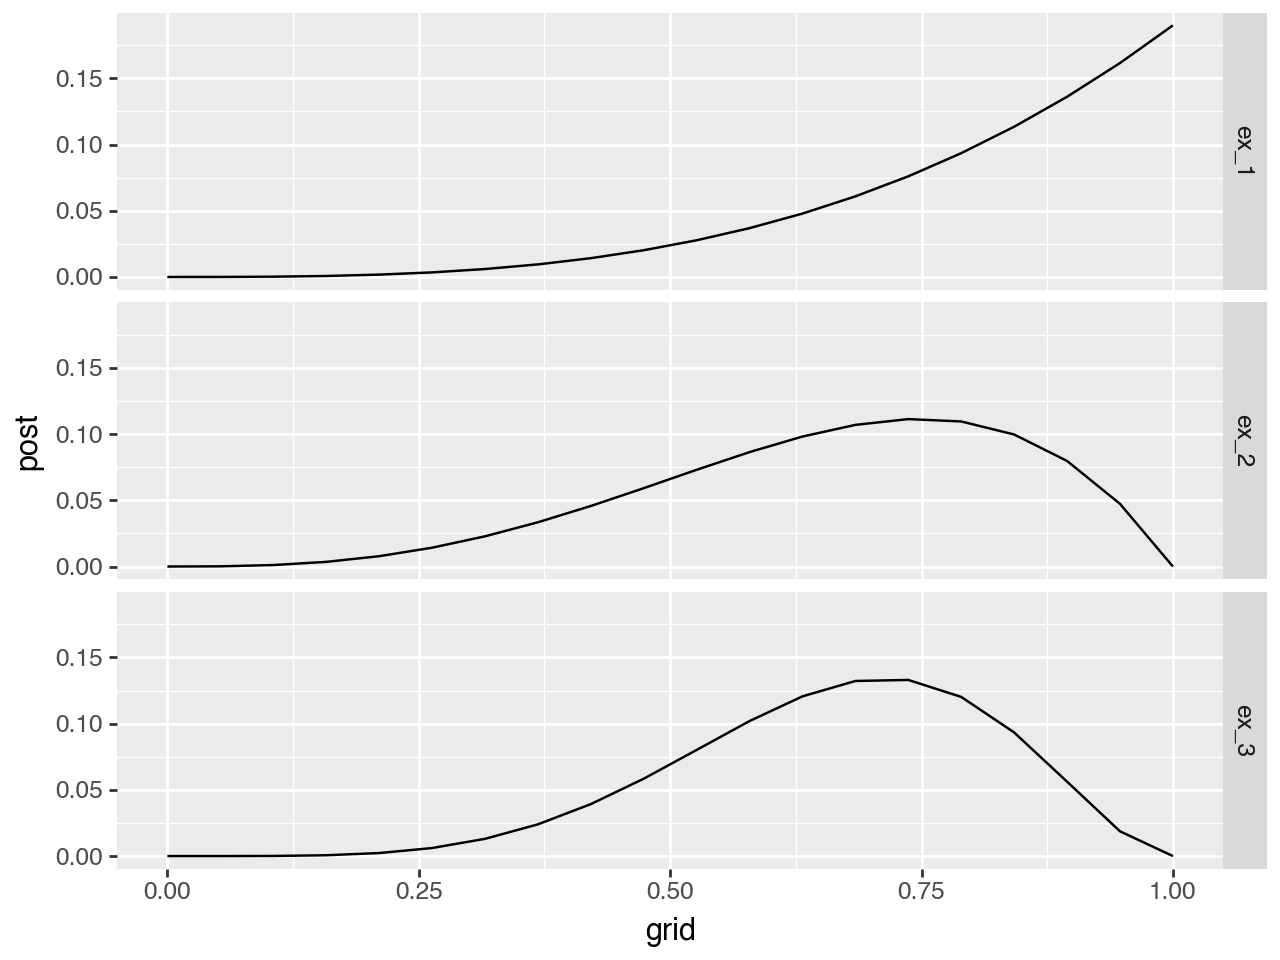

In [3]:
grid_n = 20
# Question 2M1, translating grid approx from R code on p40
# p_grid = np.linspace(0, 1, grid_n)

# # unifor prior
# prior = np.repeat(1, grid_n)

# # data, assume 1 = water, 0 = land
# ex_1 = np.array([1, 1, 1])
# ex_2 = np.array([1, 1, 1, 0])
# ex_3 = np.array([0, 1, 1, 0, 1, 1, 1])

# #likelihoods
# ex_1_l = stats.binom.pmf(k = ex_1.sum(), n = len(ex_1), p = p_grid)
# ex_1_post = (ex_1_l * prior) # un normalized / standardize
# ex_1_post = ex_1_post / sum(ex_1_post) # normalize

## loop / funciton
def grid_approx(k, total_n, grid_n = 20, prior = np.repeat(1, grid_n)):
    # grid
    p_grid = np.linspace(0, 1, grid_n)    

    #likelihoods
    ll = stats.binom.pmf(k = k, n = total_n, p = p_grid)
    
    # post 
    post = ll * prior
    post = post / sum(post)
    
    return post

df = pl.DataFrame()
for k, n, lab in zip([3, 3, 5], [3, 4, 7], ["ex_1", "ex_2", "ex_3"]):
    post = grid_approx(k, n)

    df = pl.concat([df, pl.DataFrame({
        "post": post,
        "grid": np.linspace(0, 1, len(post)), 
        "label": lab 
        })])

(
    p9.ggplot(df) +
    p9.geom_line(p9.aes(x = 'grid', y = 'post'))+
    p9.facet_grid('label')
)


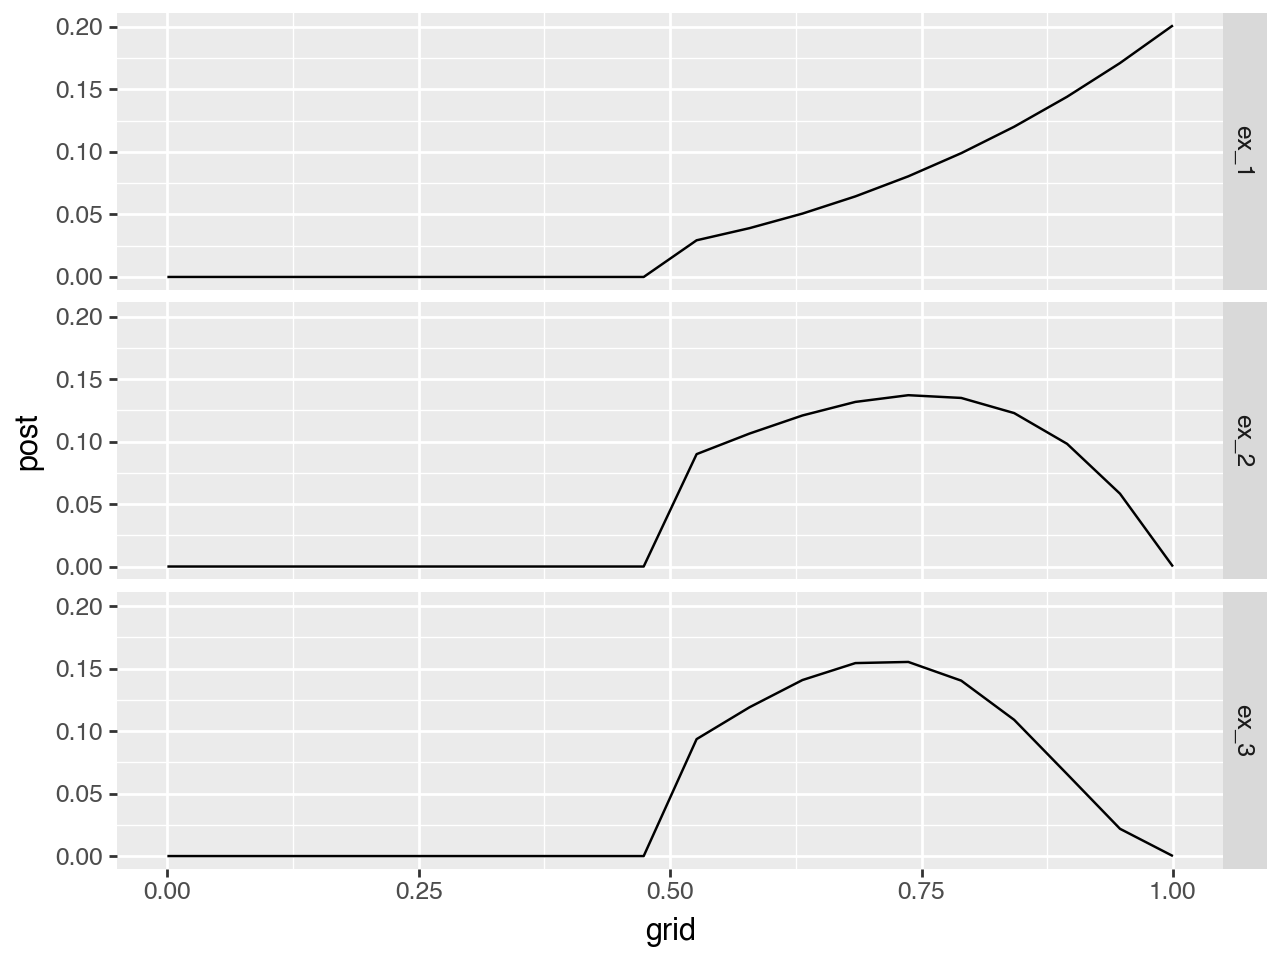

In [ ]:
# 2m2
df = pl.DataFrame()
for k, n, lab in zip([3, 3, 5], [3, 4, 7], ["ex_1", "ex_2", "ex_3"]):
    post = grid_approx(k, n, 20, np.where(p_grid < .5, 0, 1)) # prior where 0 < .5 and 1 >= .5

    df = pl.concat([df, pl.DataFrame({
        "post": post,
        "grid": np.linspace(0, 1, len(post)), 
        "label": lab 
        })])

(
    p9.ggplot(df) +
    p9.geom_line(p9.aes(x = 'grid', y = 'post'))+
    p9.facet_grid('label')
)


In [ ]:
#2m3 
p_w_e = .7
p_w_m = 0
p_earth = .5
p_mars = 1 - p_earth

# p(l|e)p(e) = p(e|l)p(l) equality
# we want p(e|l) which is
# p(e|l) = (p(l|e)p(e)) / p(l)
# p(l) = p(l|e)p(e) + p(|m)p(m)

p_l_e = 1-p_w_e
p_e = p_earth
# p_l is prob of land conditional on earth * prob earth + prob of land conditional on mars * prob mars
p_l = ((1-p_w_e) * p_e) + ((1-p_w_m) * p_mars)

post = (p_l_e * p_e) / p_l
# post = post / sum
post

0.23076923076923078

# 2m4
- 3 cards, 2 sides
- card1: 2 black sides 
- card2: 1 black / 1 white
- card3: 2 white
- randomly chose card, top side is black
- show p the bottom side of chosen card is black is 2/3
- use counting approach

We can chose one of 6 possibilities for top side of first card: 3 black and 3 white
    B   B   B   W   W   W
    BB  BB  BW  

It is 2/3 b we have 3 possible outcomes going down the black route. We've either chosen the black / black card which produces 2 BB outcomes (the outcomes that would give us a black on bottom) or the black / white card which would give us a BW. 
The other options do not matter since we didn't see white

In [ ]:
# 2M5
#Now suppose there are four cards: BB, BB, BW, WW
# do this using bayes theorem

# P(B|BB)P(BB) = P(BB|B)P(B)
# P(BB|B) = P(B|BB)P(BB) / P(B) we want a double black conditional on seeing black

p_b = 5 / 8 # p any side black
p_b_bb = 1 # by definition
p_bb = 2 / 4 # n cards bb

(p_b_bb * p_bb) / p_b


0.8

In [ ]:
# 2M6
# weighted sides
# BB, BW, WW
# black is heavier so relative chances of pulls are 
# BB: 1, BW: 2, WW: 3

# this is adjusting our prior distribution for each card

p_bb = 1 / 6
p_bw = 2 / 6
p_ww = 3 / 6
# P(BB|B) = P(B|BB)P(BB) / P(B) we want a double black conditional on seeing black

p_b = (1 * p_bb) + (.5 * p_bw) + (0 * p_ww) # p(b|bb)p(bb) + p(b|bw)p(bw) + p(b|ww)p(ww)
p_b_bb = 1

(p_b_bb * p_bb) / p_b



0.5

# 2M7
Same as 2m4 but now we draw another card and it is face up white

We can chose one of 6 possibilities for top side of first card: 3 black and 3 white
    BB -> WB
    BB -> WB
    BB -> WW
    BW -> WW


3 of 4 ways this sequence can occure have BB as the first card

In [24]:
# 2 species of pandas, one has twins 10% of time other has twins 20% of time
p_a = .5 # equally likely 
p_b = 1 - p_a
p_twins_a = .1 # twin percents
p_twins_b = .2

# what is prob of twins conditional on having twins w/o knowing species
# p(t2|t1)
# p(t1) = p(a) * p(twins|a) + p(b) * p(twins|b)
# p(t2) = p(t1) same chance always
# P(A|B) = P(A and B) / P(B)
# p(t1|t2) = (p(t1) * p(t2)) / p(t2)

# p(t2|t1)p(t1) = p(t1|t2)p(t2)
# p(t2|t1) =  p(t1|t2)p(t2) / p(t1)

p_t1 = (p_a * p_twins_a) + (p_b + p_twins_b)
p_t2 = p_t1
p_t1_t2 = (p_t1 * p_t2) / p_t2

(p_t1_t2 * p_t2) / p_t1



0.75